# Life Expectancy Prediction — Multivariate Linear Regression
### Summative: First Model Deployment

**Mission:** *To live each day with creativity, curiosity, and responsibility, inspiring innovation through
technology and using my engineering skills to improve healthcare outcomes in Africa through digital solutions.*

**Problem (regression):** Given a country's health-system and socio-economic indicators, **predict its average
life expectancy (in years)**. Life expectancy is the single most-used summary of population health, so a model
that explains *which* levers move it — schooling, immunization coverage, adult mortality, HIV/AIDS prevalence,
nutrition — is a decision-support tool for health ministries and NGOs allocating scarce resources across Africa.
The target is a **continuous value**, which makes this a regression problem rather than a classification one.

**Dataset:** *Life Expectancy (WHO)* — World Health Organization + United Nations data, 193 countries, 2000–2015.
2,938 rows × 22 columns. Source (Kaggle, Kumar Rajarshi): https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
(mirror used to load the CSV in this notebook: EvidenceN/DataSets on GitHub).

## 1. Imports & configuration
We use **scikit-learn** for the models, pandas/numpy for data handling, and matplotlib/seaborn for
visualization. `random_state=42` everywhere makes the whole notebook reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

Libraries loaded.


## 2. Load the data & inspect
First look at shape, column names (the raw CSV has stray spaces in headers — we strip them), data types, and a
statistical summary. This tells us the *volume* (2,938 rows) and *variety* (22 mixed numeric + categorical
columns) that make the dataset rich enough for regression.

In [2]:
df = pd.read_csv("Life_Expectancy_Data.csv")
df.columns = df.columns.str.strip()          # clean stray spaces in headers
print("Shape:", df.shape)
df.head()

Shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


## 3. Convert categorical data to numeric
Machine-learning models only accept numbers, so we must decide **which columns need converting**. Here the only
non-numeric predictor is **`Status`** (`Developing` / `Developed`). Because it has just two categories we map it
to a single 0/1 indicator (`Status_encoded`). `Country` is also text, but it is a high-cardinality **identifier**
(193 unique values) — encoding it would let the model memorize countries and overfit, so we will *drop* it rather
than convert it (feature-engineering decision, explained in §5).

In [5]:
df['Status_encoded'] = (df['Status'] == 'Developed').astype(int)
print(df['Status'].value_counts())
print("\nEncoded example:", df[['Status','Status_encoded']].drop_duplicates().to_dict('records'))

Status
Developing    2426
Developed      512
Name: count, dtype: int64

Encoded example: [{'Status': 'Developing', 'Status_encoded': 0}, {'Status': 'Developed', 'Status_encoded': 1}]


## 4. Missing-value audit
Feature engineering starts with knowing where the holes are. Several columns are heavily incomplete
(`Population` 22%, `Hepatitis B` 19%, `GDP` 15%). Columns that are both *weakly correlated* with the target and
*heavily missing* are prime drop candidates; columns we keep will be imputed with the **median** (robust to the
heavy right-skew we see in GDP/expenditure).

In [6]:
miss = (df.isna().mean()*100).round(1).sort_values(ascending=False)
miss[miss>0]

Population                         22.2
Hepatitis B                        18.8
GDP                                15.2
Total expenditure                   7.7
Alcohol                             6.6
Income composition of resources     5.7
Schooling                           5.5
thinness  1-19 years                1.2
thinness 5-9 years                  1.2
BMI                                 1.2
Polio                               0.6
Diphtheria                          0.6
Life expectancy                     0.3
Adult Mortality                     0.3
dtype: float64

## 5. Visualization & interpretation
After each plot, the interpretation notes explain what the pattern means for the model.

### 5a. Correlation heatmap
Which variables actually move life expectancy, and which move together (redundancy)?

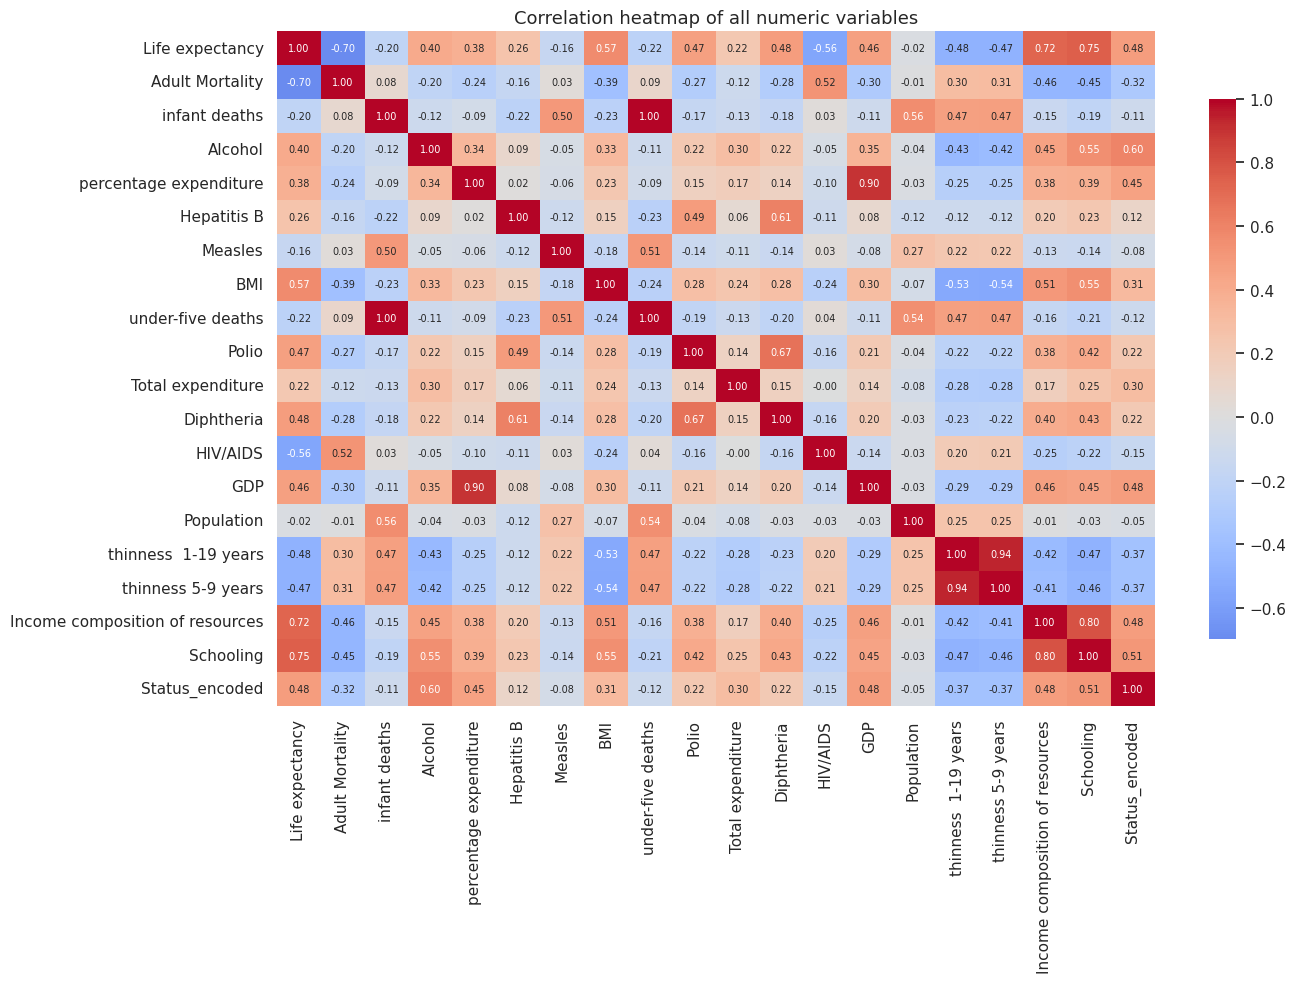

In [7]:
num = df.select_dtypes(include=[np.number]).drop(columns=['Year'])
plt.figure(figsize=(14,10))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size":7}, cbar_kws={"shrink":.8})
plt.title("Correlation heatmap of all numeric variables", fontsize=13)
plt.tight_layout(); plt.savefig("plot_correlation_heatmap.png", dpi=120, bbox_inches="tight"); plt.show()

**Interpretation.** The `Life expectancy` row is what matters. **Positive drivers:** `Schooling` (+0.75),
`Income composition of resources` (+0.73), `BMI` (+0.57), `Diphtheria` immunization (+0.48), `GDP` (+0.46).
**Negative drivers:** `Adult Mortality` (−0.70), `HIV/AIDS` (−0.56), `thinness` (−0.48). We also spot
**redundancy**: `infant deaths`↔`under-five deaths` (~0.997), the two `thinness` columns (~0.94), and
`Polio`↔`Diphtheria` — keeping both of each pair adds multicollinearity without new signal, so we keep one of
each. `Population` is essentially uncorrelated (−0.02) and 22% missing → drop.

### 5b. Target distribution & key feature distributions
Histograms show the shape of each variable (skew, spread, outliers), which justifies **median** imputation and
**standardization** later.

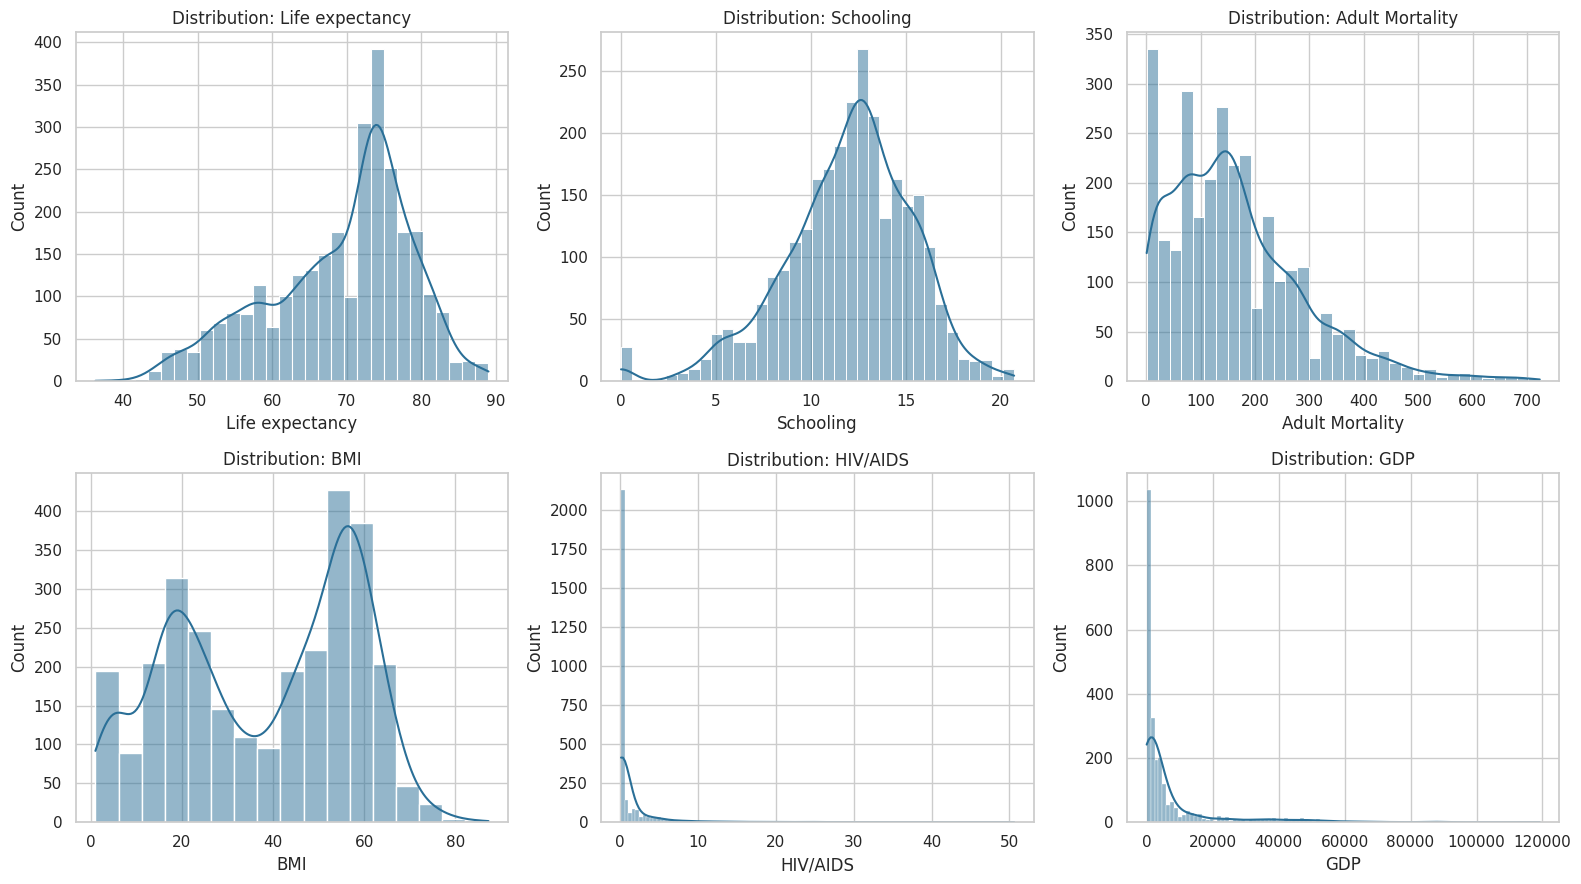

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.ravel(),
        ['Life expectancy','Schooling','Adult Mortality','BMI','HIV/AIDS','GDP']):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#2a6f97")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout(); plt.savefig("plot_distributions.png", dpi=120, bbox_inches="tight"); plt.show()

**Interpretation.** Life expectancy is left-skewed (most countries 60–80 yrs, a low tail of crisis states).
`GDP`, `HIV/AIDS` and `Adult Mortality` are strongly right-skewed with long tails → the **median** is a safer fill
value than the mean, and features on wildly different scales (GDP in thousands vs BMI ~20–60) confirm we **must
standardize** before the gradient-descent / distance-sensitive models.

### 5c. Scatter plots vs the target
Do the relationships look linear enough for a linear model?

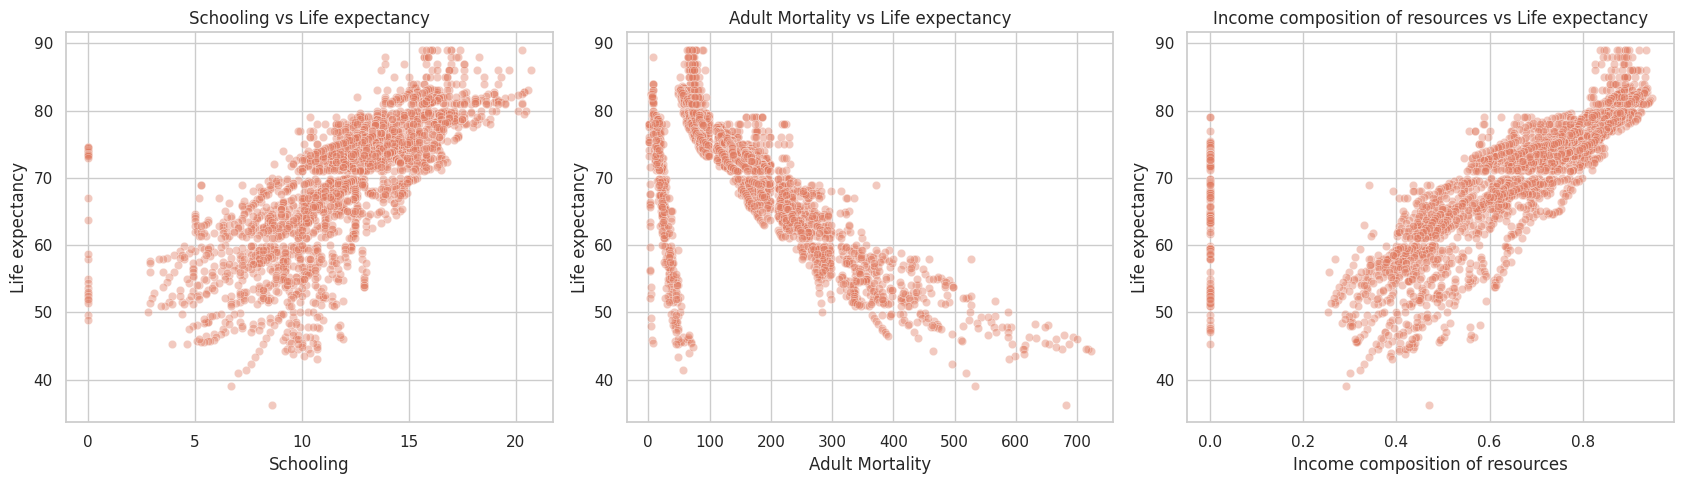

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
for ax, col in zip(axes, ['Schooling','Adult Mortality','Income composition of resources']):
    sns.scatterplot(x=df[col], y=df['Life expectancy'], ax=ax, alpha=0.4, color="#e07a5f")
    ax.set_title(f"{col} vs Life expectancy")
plt.tight_layout(); plt.savefig("plot_scatter_relationships.png", dpi=120, bbox_inches="tight"); plt.show()

**Interpretation.** `Schooling` and `Income composition` rise with life expectancy in a broadly **linear**
band (good for linear regression), while `Adult Mortality` falls but with **curvature** at the extremes — a hint
that a non-linear model (tree/ensemble) may ultimately fit better. This visual is exactly why we compare linear
and tree-based models below.

## 6. Feature engineering — final selection
Putting the audit together, we **drop**: `Country` (identifier → overfitting), `Year` (time index, not a health
lever), `Population` (~0 correlation, 22% missing), `Hepatitis B` (19% missing + weak), `Measles` &
`percentage expenditure` (weak / redundant with GDP), and the redundant halves of each collinear pair
(`infant deaths`, `under-five deaths`, `Polio`, `thinness 5-9 years`). We **keep 8 strong, non-redundant,
interpretable predictors**. Rows with a missing **target** are dropped (you can't learn from an unknown label);
remaining feature gaps are **median-imputed**.

In [10]:
FEATURES = ['Adult Mortality', 'BMI', 'HIV/AIDS', 'GDP',
            'Income composition of resources', 'Schooling',
            'Diphtheria', 'thinness  1-19 years']
TARGET = 'Life expectancy'

data = df[FEATURES + [TARGET]].copy()
data = data.dropna(subset=[TARGET])                       # drop rows w/o a label
for c in FEATURES:                                        # median-impute feature gaps
    data[c] = data[c].fillna(data[c].median())

print("Final modelling frame:", data.shape)
print("Any missing left?", int(data.isna().sum().sum()))
data.head()

Final modelling frame: (2928, 9)
Any missing left? 0


,Adult Mortality,BMI,HIV/AIDS,GDP,Income composition of resources,Schooling,Diphtheria,thinness 1-19 years,Life expectancy
0,263.0,19.1,0.1,584.259210,0.479,10.1,65.0,17.2,65.0
1,271.0,18.6,0.1,612.696514,0.476,10.0,62.0,17.5,59.9
2,268.0,18.1,0.1,631.744976,0.470,9.9,64.0,17.7,59.9
3,272.0,17.6,0.1,669.959000,0.463,9.8,67.0,17.9,59.5
4,275.0,17.2,0.1,63.537231,0.454,9.5,68.0,18.2,59.2


## 7. Train / test split
80% train / 20% test, fixed seed. The test set is held out from all fitting so every reported metric is honest.

In [11]:
X = data[FEATURES].values
y = data[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2342, 8)  Test: (586, 8)


## 8. Standardization
We fit `StandardScaler` **on the training data only** (so no information leaks from test into training) and apply
it to both. Standardization (mean 0, variance 1) is essential for **gradient descent** — features on huge scales
(GDP) would otherwise dominate the gradient and make convergence unstable.

In [12]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Scaled train mean≈0:", np.round(X_train_s.mean(axis=0),3)[:4], "...")
print("Scaled train std ≈1:", np.round(X_train_s.std(axis=0),3)[:4], "...")

Scaled train mean≈0: [0. 0. 0. 0.] ...
Scaled train std ≈1: [1. 1. 1. 1.] ...


## 9. Gradient-descent linear regression + loss curves
`SGDRegressor` is scikit-learn's **stochastic gradient descent** linear regressor. We train it epoch-by-epoch with
`partial_fit` and record the **Mean Squared Error on both the train and test sets after every epoch** to build the loss
curve. A gap opening between the two curves would signal over- or under-fitting.

In [13]:
sgd_curve = SGDRegressor(loss='squared_error', penalty='l2', alpha=1e-4,
                         learning_rate='invscaling', eta0=0.01, random_state=RANDOM_STATE)
n_epochs = 200
train_loss, test_loss = [], []
for epoch in range(n_epochs):
    sgd_curve.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, sgd_curve.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test,  sgd_curve.predict(X_test_s)))
print(f"Final MSE  train={train_loss[-1]:.3f}  test={test_loss[-1]:.3f}")

Final MSE  train=18.262  test=16.885


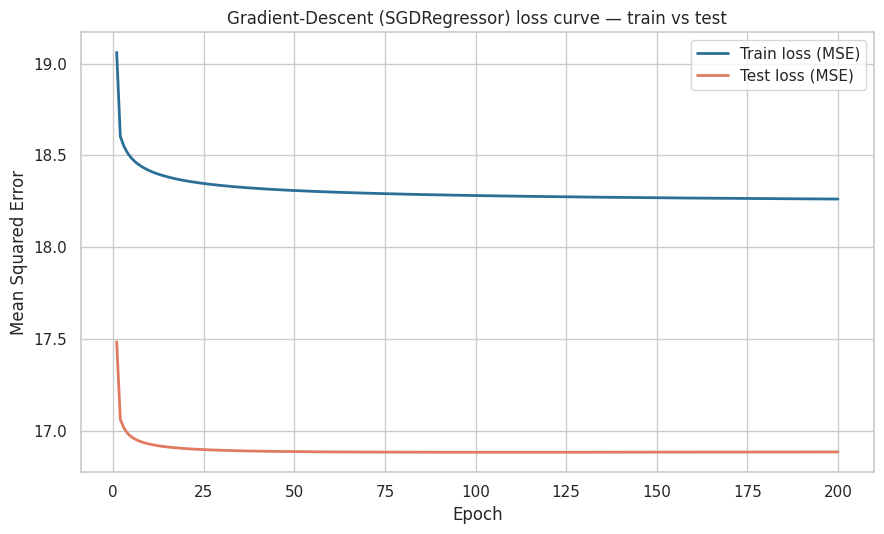

In [14]:
plt.figure(figsize=(9,5.5))
plt.plot(range(1,n_epochs+1), train_loss, label="Train loss (MSE)", color="#2a6f97", lw=2)
plt.plot(range(1,n_epochs+1), test_loss,  label="Test loss (MSE)",  color="#e07a5f", lw=2)
plt.xlabel("Epoch"); plt.ylabel("Mean Squared Error")
plt.title("Gradient-Descent (SGDRegressor) loss curve — train vs test")
plt.legend(); plt.tight_layout()
plt.savefig("plot_loss_curve.png", dpi=120, bbox_inches="tight"); plt.show()

**Interpretation.** Both curves fall steeply then flatten to a low plateau, and the **train and test lines sit
almost on top of each other** — the model converges and does **not** overfit. The plateau (~17 MSE, i.e. RMSE≈4
years) is the floor of what a *straight-line* model can achieve on this data; beating it requires a non-linear
model (§11).

## 10. Optimize the gradient-descent model
We tune the SGD hyper-parameters (regularization strength `alpha`, initial learning rate `eta0`, schedule) with
`GridSearchCV` (5-fold) to get the best possible *linear* model before comparing families.

In [15]:
grid = GridSearchCV(
    SGDRegressor(loss='squared_error', max_iter=3000, random_state=RANDOM_STATE),
    param_grid={'alpha':[1e-5,1e-4,1e-3], 'eta0':[0.005,0.01,0.05],
                'learning_rate':['invscaling','adaptive']},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train_s, y_train)
print("Best SGD params:", grid.best_params_)
sgd_best = grid.best_estimator_
print("Tuned SGD test RMSE:", mean_squared_error(y_test, sgd_best.predict(X_test_s))**0.5)

Best SGD params: {'alpha': 0.001, 'eta0': 0.05, 'learning_rate': 'adaptive'}
Tuned SGD test RMSE: 4.116855516093649


## 11. Compare 4 regression algorithms
We compare **stochastic gradient-descent linear regression** against three other implementations:
closed-form **OLS Linear Regression**, a **Decision Tree**, and a **Random Forest** (ensemble). Each is wrapped in
a `Pipeline` with its own scaler so the comparison is apples-to-apples and the saved artifact is self-contained.
We rank by **test RMSE** (the loss in the target's own units — years).

In [16]:
models = {
 'SGD (Gradient Descent)': Pipeline([('scaler',StandardScaler()),
        ('m',SGDRegressor(loss='squared_error', penalty='l2',
              alpha=grid.best_params_['alpha'], eta0=grid.best_params_['eta0'],
              learning_rate=grid.best_params_['learning_rate'],
              max_iter=3000, random_state=RANDOM_STATE))]),
 'Linear Regression (OLS)': Pipeline([('scaler',StandardScaler()),
        ('m',LinearRegression())]),
 'Decision Tree': Pipeline([('scaler',StandardScaler()),
        ('m',DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE))]),
 'Random Forest': Pipeline([('scaler',StandardScaler()),
        ('m',RandomForestRegressor(n_estimators=100, max_depth=10,
              random_state=RANDOM_STATE, n_jobs=-1))]),
}
rows=[]
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict(X_test)
    rows.append({'Model':name,
                 'MSE':mean_squared_error(y_test,p),
                 'RMSE':mean_squared_error(y_test,p)**0.5,
                 'MAE':mean_absolute_error(y_test,p),
                 'R2':r2_score(y_test,p)})
results = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
results.round(3)

,Model,MSE,RMSE,MAE,R2
0,Random Forest,3.390,1.841,1.211,0.961
1,Decision Tree,6.763,2.600,1.834,0.922
2,SGD (Gradient Descent),16.948,4.117,3.040,0.804
3,Linear Regression (OLS),16.951,4.117,3.039,0.804


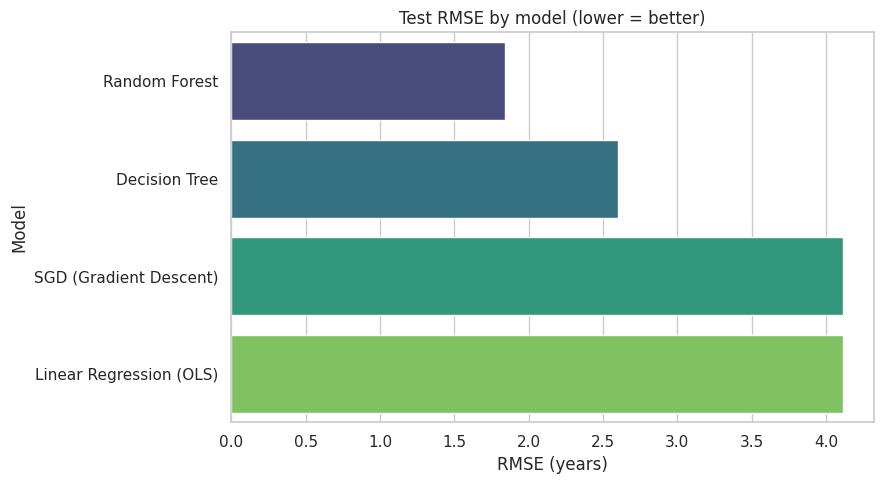

BEST model (least loss): Random Forest


In [17]:
plt.figure(figsize=(9,5))
sns.barplot(data=results, x='RMSE', y='Model', palette='viridis')
plt.title("Test RMSE by model (lower = better)"); plt.xlabel("RMSE (years)")
plt.tight_layout(); plt.savefig("plot_model_comparison.png", dpi=120, bbox_inches="tight"); plt.show()
best_name = results.iloc[0]['Model']
print("BEST model (least loss):", best_name)

**Interpretation / basis for 'best'.** We select the model with the **least test loss (lowest RMSE / MSE,
highest R²)**. The two linear models tie at R²≈0.80 (RMSE≈4.1 yrs) — they capture the dominant linear trend. The
**Random Forest wins clearly (R²≈0.96, RMSE≈1.8 yrs)** because the true relationships (e.g. Adult Mortality, HIV)
are non-linear and involve interactions a straight line can't express. That is the justified basis for saving the
Random Forest as the deployed model, while still building and optimizing the gradient-descent linear model
for comparison.

## 12. Best-fit line — scatter *before* and *after*
Left: raw data (no model). Right: the same data with the fitted **linear regression line** drawn through it. We
use the strongest single predictor (`Income composition of resources`) so the line is meaningful in 2-D.

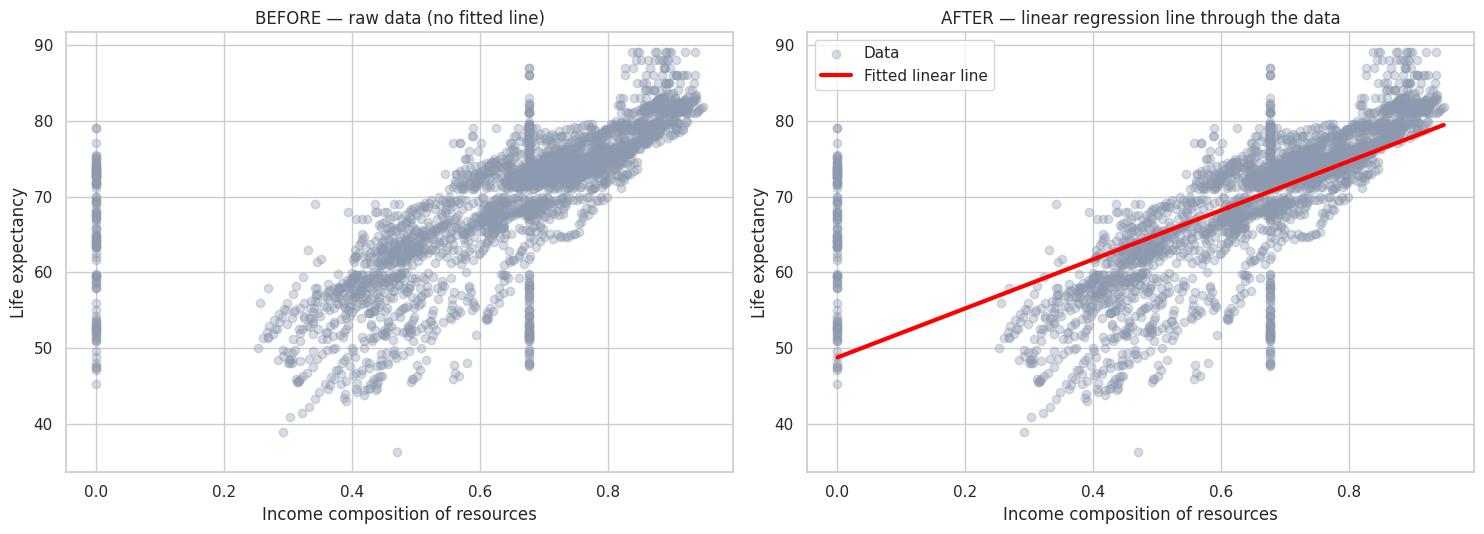

In [18]:
feat = 'Income composition of resources'
xf = data[feat].values.reshape(-1,1)
yf = data[TARGET].values
xtr,xte,ytr2,yte2 = train_test_split(xf,yf,test_size=0.2,random_state=RANDOM_STATE)
lin1 = LinearRegression().fit(xtr,ytr2)
xline = np.linspace(xf.min(), xf.max(), 100).reshape(-1,1)

fig, ax = plt.subplots(1,2, figsize=(15,5.5))
ax[0].scatter(xf, yf, alpha=0.35, color="#8d99ae")
ax[0].set_title("BEFORE — raw data (no fitted line)")
ax[0].set_xlabel(feat); ax[0].set_ylabel("Life expectancy")
ax[1].scatter(xf, yf, alpha=0.35, color="#8d99ae", label="Data")
ax[1].plot(xline, lin1.predict(xline), color="red", lw=3, label="Fitted linear line")
ax[1].set_title("AFTER — linear regression line through the data")
ax[1].set_xlabel(feat); ax[1].set_ylabel("Life expectancy"); ax[1].legend()
plt.tight_layout(); plt.savefig("plot_bestfit_line.png", dpi=120, bbox_inches="tight"); plt.show()

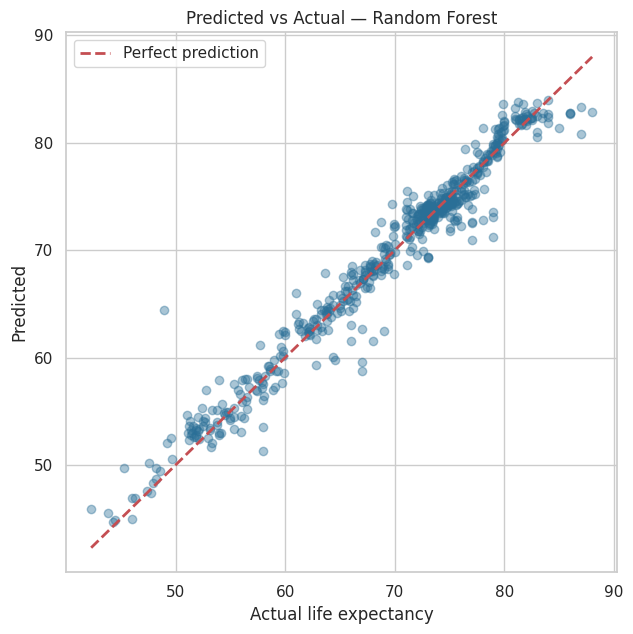

In [19]:
# Predicted-vs-actual for the BEST multivariate model (diagonal = perfect prediction)
best_model = models[best_name]
pred_best = best_model.predict(X_test)
plt.figure(figsize=(6.5,6.5))
plt.scatter(y_test, pred_best, alpha=0.4, color="#2a6f97")
lo,hi = y_test.min(), y_test.max()
plt.plot([lo,hi],[lo,hi],'r--',lw=2,label="Perfect prediction")
plt.xlabel("Actual life expectancy"); plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual — {best_name}"); plt.legend()
plt.tight_layout(); plt.savefig("plot_pred_vs_actual.png", dpi=120, bbox_inches="tight"); plt.show()

## 13. Save the best-performing model
We persist the winning **Pipeline** (scaler + model together) plus the feature list and metrics with `joblib`.
Because the scaler lives inside the pipeline, the API can feed **raw** user inputs straight in — no manual scaling
needed server-side. We save a copy into the API folder so deployment picks it up.

In [20]:
import os, shutil
artifact = {
    'pipeline': best_model,
    'features': FEATURES,
    'target': TARGET,
    'best_model_name': best_name,
    'metrics': results.set_index('Model').round(4).to_dict('index'),
    'feature_ranges': {c: [float(data[c].min()), float(data[c].max())] for c in FEATURES},
}
joblib.dump(artifact, "best_model.pkl")
os.makedirs("../API", exist_ok=True)
shutil.copy("best_model.pkl", "../API/best_model.pkl")
data.to_csv("../API/training_data.csv", index=False)   # snapshot for the /retrain endpoint
print("Saved best_model.pkl (and copied to API/). Best model:", best_name)
print("Feature ranges:"); print(json.dumps(artifact['feature_ranges'], indent=2))

Saved best_model.pkl (and copied to API/). Best model: Random Forest
Feature ranges:
{
  "Adult Mortality": [
    1.0,
    723.0
  ],
  "BMI": [
    1.0,
    77.6
  ],
  "HIV/AIDS": [
    0.1,
    50.6
  ],
  "GDP": [
    1.68135,
    119172.7418
  ],
  "Income composition of resources": [
    0.0,
    0.948
  ],
  "Schooling": [
    0.0,
    20.7
  ],
  "Diphtheria": [
    2.0,
    99.0
  ],
  "thinness  1-19 years": [
    0.1,
    27.7
  ]
}


## 14. Single-point prediction (used by the API in Task 2)
This function predicts on **a single row of the test set** and is the same logic the API reuses: take the
8 raw feature values and return a predicted life-expectancy number.

In [21]:
def predict_one(values: dict) -> float:
    """values: dict keyed by FEATURES -> predicted life expectancy (years)."""
    row = np.array([[values[f] for f in FEATURES]])
    return float(best_model.predict(row)[0])

# Demo on one real row from the test set
sample_idx = 0
sample = dict(zip(FEATURES, X_test[sample_idx]))
print("Input row:", {k: round(v,2) for k,v in sample.items()})
print("Predicted life expectancy:", round(predict_one(sample),2), "years")
print("Actual   life expectancy:", round(float(y_test[sample_idx]),2), "years")

Input row: {'Adult Mortality': np.float64(449.0), 'BMI': np.float64(46.4), 'HIV/AIDS': np.float64(19.0), 'GDP': np.float64(5888.63), 'Income composition of resources': np.float64(0.62), 'Schooling': np.float64(12.8), 'Diphtheria': np.float64(76.0), 'thinness  1-19 years': np.float64(8.1)}
Predicted life expectancy: 55.19 years
Actual   life expectancy: 56.5 years


## 15. Summary
We built a full multivariate regression pipeline for **life-expectancy prediction** on rich WHO data: cleaned and
encoded the data, engineered 8 non-redundant features, standardized, and compared **gradient-descent linear
regression** against **OLS, a decision tree, and a random forest**. The **Random Forest** gave the least loss
(RMSE≈1.8 yrs, R²≈0.96) and is saved as `best_model.pkl` for the API. The single-point `predict_one` function is
the bridge to Task 2 (FastAPI) and Task 3 (Flutter).